In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_V2_normalized.csv
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__results__.html
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/whisper_bn_lipighor_final.csv
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__huggingface_repos__.json
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/conformer_output.csv
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__notebook__.ipynb
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__output__.json
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_v2_missing_fixed.csv
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/custom.css
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__results___files/__results___25_1.png
/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/__results___files/__results___12_1.png
/kaggle/input

In [7]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_Hasan3090")

# Seamless M4T-v2

In [3]:
import os
import pandas as pd
from pathlib import Path
from huggingface_hub import hf_hub_download

# ── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN             = secret_value_0  # Replace with your actual token
OUTPUT_REPO_ID       = "hasans090/seamless_inference_lp"
DATASET_AUDIO_FOLDER = "data"
OUTPUT_CSV           = "/kaggle/working/seamless_lipighor_final.csv"
LOCAL_AUDIO_CACHE    = "/kaggle/working/audio_cache"

os.makedirs(LOCAL_AUDIO_CACHE, exist_ok=True)
print("✅ Config ready")

# ── Resume Logic ──────────────────────────────────────────────────────────────
def load_existing_csv_from_hf(output_repo, csv_filename, token):
    try:
        path = hf_hub_download(
            repo_id        = output_repo,
            filename       = csv_filename,
            repo_type      = "dataset",
            token          = token,
            force_download = True,
        )
        df = pd.read_csv(path)
        print(f"✅ Loaded from HF — {len(df)} rows done so far")
        return df
    except Exception as e:
        # This will trigger if the file doesn't exist yet (first run)
        print(f"ℹ️ No existing CSV on HF (starting fresh)")
        return pd.DataFrame() # Return empty DF instead of None for easier concatenation later

# Execute
hf_df = load_existing_csv_from_hf(OUTPUT_REPO_ID, Path(OUTPUT_CSV).name, HF_TOKEN)

✅ Config ready


seamless_lipighor_final.csv:   0%|          | 0.00/87.5M [00:00<?, ?B/s]

✅ Loaded from HF — 1019 rows done so far


In [4]:
hf_df.to_csv('seamless_lipighor_final.csv')

In [5]:
hf_df

,id,transcript
0,-1ln9OXXCGQ,আমি ডঃ মোহাম্মদ শফিউল হাসান মানসিক রোগ বিশেষজ্...
1,-6VEn1be2b0,মাই অডিওবুকে শুনছেন হুমায়ুন আহমেদ লিখিত মিশ্র...
2,-9ndd6wI7PQ,ভাড়াটা বেছে নিলে এই যে তুমি যাও না না এই যে ব...
3,-G48OneCI9Y,"মহাপ্রভু বললেন, আজকে তুমি যাকে কাঁদতে কাঁদতে স..."
4,-H7a2CHeNeo,আত্মসম্মানের ফলাফল ক্রিকেটের রাজনীতির ফলাফল বি...
...,...,...
1014,ztBhboHpJko,পাঁচশো দিনে তারা সারাদেশে ছদ্মবেশ করেছে পাঁচশো...
1015,ztal_wYKQqs,পরশেবৈধ্য নয়াবাজারে একটা কাপড়ের দোকানে কাজ ক...
1016,zufNXsMP7rc,হাজরাত আব্বাস রাজিউল্লাহ বলেন নবী (সাল্লাল্লাহ...
1017,zydBQdUiHQQ,যেভাবে হঠাৎ ভূমিকম্প হয় পিস্তলের গুলিও ঠিক সে...


In [6]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.1 MB/s eta 0:00:0000:0100:01


In [7]:
df_text = pd.read_csv('/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_V2_normalized.csv')

In [8]:
df_text

,video_id,text,char_count
0,-1ln9OXXCGQ,আমি ডাক্তার মোহাম্মদ শফিউল হাসান মানসিক রোগ বি...,7597
1,-6VEn1be2b0,মিউজিক মাই অডিও বুকে শুনছেন হুমায়ন আহমেদ লিখি...,25466
2,-9ndd6wI7PQ,ালার টা বেসলার ভাসা দুনিয়ার জ্বালা মর বাইর দর...,2020
3,-G48OneCI9Y,মহাপ্রভু বললেন আজকে তুমি যাকে কাঁধে করে শ্মশান...,39573
4,-H7a2CHeNeo,আত্মমর্যাদা বনাম ক্রিকেট রাজনীতির দৈরথের ফলাফল...,4924
...,...,...,...
1014,ztal_wYKQqs,পরেশ বৈদ্য নয়াবাজারে একটা কাপড়ের দোকানে কাজ ...,55581
1015,zufNXsMP7rc,হযরত আব্বাস রাদিয়াল্লাহু আনহু বলেন নবী গো দুন...,36676
1016,zydBQdUiHQQ,যেভাবে হঠাৎ ভূমিকম্প হয় পিস্তলের গুলিও ঠিক সে...,46256
1017,zzG2-o1xAQ0,আওয়ামী লীগ ছাড়া নির্বাচনের মাধ্যমে যে নির্বা...,17865


In [9]:
df_meta = pd.read_csv('/kaggle/input/datasets/sanjidh090/lipighor-metadata/lipi_ghor_metadata (1).csv')

In [10]:
df_meta

,video_id,channel_id,channel_name,duration_sec,category,video_url
0,-1ln9OXXCGQ,UCeuvxGn6xJB-4KbRGJYwf0A,Dr. Mahbubur Rahman,565.0,Waz,https://www.youtube.com/watch?v=-1ln9OXXCGQ
1,-6VEn1be2b0,UCF7USNwvrBhFCXsohC_U9ag,My AudioBook,2494.0,Audio-book,https://www.youtube.com/watch?v=-6VEn1be2b0
2,-9ndd6wI7PQ,UCBQ-OHytz7N-iP8G4bdb18w,Rangpur Funny Video,303.0,Comedy / Satire,https://www.youtube.com/watch?v=-9ndd6wI7PQ
3,-G48OneCI9Y,UC7De0oUYmSy8CCefqdHQP3Q,Sonatony Songo,5792.0,Music,https://www.youtube.com/watch?v=-G48OneCI9Y
4,-H7a2CHeNeo,UCz8kD6OLDUGgq7QqTN3nIyQ,Newsalap,352.0,Political,https://www.youtube.com/watch?v=-H7a2CHeNeo
...,...,...,...,...,...,...
1014,ztBhboHpJko,UCA4y9g_GRdNrZLH_u5LLSdw,Banglavision Drama,340.0,Natok,https://www.youtube.com/watch?v=ztBhboHpJko
1015,ztal_wYKQqs,UCJJYxWhu77PG_o7nbU_2tXQ,Audio Book Bangla by Faheem,4699.0,Audio-book,https://www.youtube.com/watch?v=ztal_wYKQqs
1016,zufNXsMP7rc,UC4TirhUjxScWpuLyPQxph7w,Islamic Waz HD TV,3761.0,Waz,https://www.youtube.com/watch?v=zufNXsMP7rc
1017,zydBQdUiHQQ,UCvoC1eVphUAe7a0m-uuoPbg,Bongo,6682.0,Movie,https://www.youtube.com/watch?v=zydBQdUiHQQ


In [11]:
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("========================================")
print(" 🚀 LIPI-GHOR ASR EVALUATION PIPELINE")
print("========================================")

# --- 1. Load and Merge Data ---
# Load predictions
df_pred = pd.read_csv('/kaggle/working/seamless_lipighor_final.csv')

# Rename columns so they align perfectly
df_pred = df_pred.rename(columns={'id': 'video_id', 'transcript': 'prediction'})

# Merge Ground Truth (df_text) + Predictions (df_pred) + Metadata (df_meta)
df_eval = pd.merge(df_text, df_pred, on='video_id', how='inner')
df_eval = pd.merge(df_eval, df_meta[['video_id', 'category', 'duration_sec']], on='video_id', how='inner')

# Drop any rows where extraction failed
df_eval = df_eval.dropna(subset=['text', 'prediction'])

# --- 2. Clean Text for Fair Evaluation ---
# Punctuation and extra spaces artificially inflate WER. We must remove them.
def clean_for_eval(t):
    t = str(t).strip()
    t = re.sub(r'[^\w\s]', '', t) # Remove punctuation
    t = re.sub(r'\s+', ' ', t)    # Normalize spaces
    return t

df_eval['gt_clean'] = df_eval['text'].apply(clean_for_eval)
df_eval['pred_clean'] = df_eval['prediction'].apply(clean_for_eval)

# Ensure no empty strings are passed to jiwer (causes division by zero)
df_eval = df_eval[(df_eval['gt_clean'].str.len() > 0)]
# Fill empty predictions with a blank space to penalize them properly
df_eval['pred_clean'] = df_eval['pred_clean'].replace('', ' ') 

print(f"✅ Data Merged & Cleaned. Total valid utterances for evaluation: {len(df_eval):,}")

 🚀 LIPI-GHOR ASR EVALUATION PIPELINE
✅ Data Merged & Cleaned. Total valid utterances for evaluation: 1,019


In [12]:
# --- 3. Global Metrics (UPDATED FOR JIWER 3.0+) ---
ground_truths = df_eval['gt_clean'].tolist()
predictions = df_eval['pred_clean'].tolist()

# Calculate metrics individually
global_wer = jiwer.wer(ground_truths, predictions)
global_cer = jiwer.cer(ground_truths, predictions)
global_mer = jiwer.mer(ground_truths, predictions)
global_wil = jiwer.wil(ground_truths, predictions)

print("\n--- 🌍 Global ASR Performance ---")
print(f"Global WER (Word Error Rate):       {global_wer * 100:.2f}%")
print(f"Global CER (Character Error Rate):  {global_cer * 100:.2f}%")
print(f"Global MER (Match Error Rate):      {global_mer * 100:.2f}%")
print(f"Global WIL (Word Information Lost): {global_wil * 100:.2f}%")

# --- 4. Domain-Based Evaluation (UPDATED) ---
print("\n--- 📊 Domain-Based WER & CER ---")
def get_metrics(df_group):
    gt = df_group['gt_clean'].tolist()
    pr = df_group['pred_clean'].tolist()
    
    return pd.Series({
        'WER %': jiwer.wer(gt, pr) * 100, 
        'CER %': jiwer.cer(gt, pr) * 100,
        'Files': len(df_group)
    })

domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
print(domain_stats.round(2))

# --- 5. Duration-Based Evaluation (UPDATED) ---
print("\n--- ⏱️ Duration-Based WER ---")
# Split durations into 4 equal quartiles (Short, Medium, Long, Very Long)
df_eval['duration_bin'] = pd.qcut(df_eval['duration_sec'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)
print(duration_stats.round(2))


--- 🌍 Global ASR Performance ---
Global WER (Word Error Rate):       66.71%
Global CER (Character Error Rate):  45.54%
Global MER (Match Error Rate):      57.47%
Global WIL (Word Information Lost): 76.71%

--- 📊 Domain-Based WER & CER ---


/tmp/ipykernel_55/2464990262.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
/tmp/ipykernel_55/2464990262.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


                     WER %  CER %  Files
category                                
Audio-book           57.09  37.25  277.0
News                 57.83  37.95   35.0
Political            63.59  43.86   29.0
Commentary           63.70  43.76   13.0
Talk-show            64.81  44.35  176.0
Health               65.81  46.05    2.0
Cartoon              68.23  44.35   23.0
Podcast              68.65  49.44   62.0
Education            69.83  49.32   39.0
Service / Promo      71.08  52.28    2.0
Vlog                 73.20  52.97   42.0
Natok                73.94  52.53   95.0
Waz                  74.27  51.06   66.0
Music                77.68  52.22   37.0
Movie                79.21  54.45   74.0
Comedy / Satire      85.37  60.02   43.0
Regional / Dialect  113.70  78.09    4.0

--- ⏱️ Duration-Based WER ---
              WER %  CER %  Files
duration_bin                     
Short         66.11  44.94  255.0
Medium        64.49  43.80  255.0
Long          63.55  43.12  254.0
Very Long     70.13 

/tmp/ipykernel_55/2464990262.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


# Meta mms 1B

In [5]:
import os
import pandas as pd
from pathlib import Path
from huggingface_hub import hf_hub_download

# ── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN             = secret_value_0  # Replace with your actual token
OUTPUT_REPO_ID       = "hasans090/mms_inference_lp"
DATASET_AUDIO_FOLDER = "data"
OUTPUT_CSV           = "/kaggle/working/mms_lipighor_final.csv"
LOCAL_AUDIO_CACHE    = "/kaggle/working/audio_cache"

os.makedirs(LOCAL_AUDIO_CACHE, exist_ok=True)
print("✅ Config ready")

# ── Resume Logic ──────────────────────────────────────────────────────────────
def load_existing_csv_from_hf(output_repo, csv_filename, token):
    try:
        path = hf_hub_download(
            repo_id        = output_repo,
            filename       = csv_filename,
            repo_type      = "dataset",
            token          = token,
            force_download = True,
        )
        df = pd.read_csv(path)
        print(f"✅ Loaded from HF — {len(df)} rows done so far")
        return df
    except Exception as e:
        # This will trigger if the file doesn't exist yet (first run)
        print(f"ℹ️ No existing CSV on HF (starting fresh)")
        return pd.DataFrame() # Return empty DF instead of None for easier concatenation later

# Execute
hf_df = load_existing_csv_from_hf(OUTPUT_REPO_ID, Path(OUTPUT_CSV).name, HF_TOKEN)

✅ Config ready
ℹ️ No existing CSV on HF (starting fresh)


In [6]:
hf_df.to_csv('mms_lipighor_final.csv')

In [15]:
!pip install jiwer

In [16]:
df_text = pd.read_csv('/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_V2_normalized.csv')
df_meta = pd.read_csv('/kaggle/input/datasets/sanjidh090/lipighor-metadata/lipi_ghor_metadata (1).csv')

In [17]:
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("========================================")
print(" 🚀 LIPI-GHOR ASR EVALUATION PIPELINE")
print("========================================")

# --- 1. Load and Merge Data ---
# Load predictions
df_pred = pd.read_csv('/kaggle/working/mms_lipighor_final.csv')

# Rename columns so they align perfectly
df_pred = df_pred.rename(columns={'id': 'video_id', 'transcript': 'prediction'})

# Merge Ground Truth (df_text) + Predictions (df_pred) + Metadata (df_meta)
df_eval = pd.merge(df_text, df_pred, on='video_id', how='inner')
df_eval = pd.merge(df_eval, df_meta[['video_id', 'category', 'duration_sec']], on='video_id', how='inner')

# Drop any rows where extraction failed
df_eval = df_eval.dropna(subset=['text', 'prediction'])

# --- 2. Clean Text for Fair Evaluation ---
# Punctuation and extra spaces artificially inflate WER. We must remove them.
def clean_for_eval(t):
    t = str(t).strip()
    t = re.sub(r'[^\w\s]', '', t) # Remove punctuation
    t = re.sub(r'\s+', ' ', t)    # Normalize spaces
    return t

df_eval['gt_clean'] = df_eval['text'].apply(clean_for_eval)
df_eval['pred_clean'] = df_eval['prediction'].apply(clean_for_eval)

# Ensure no empty strings are passed to jiwer (causes division by zero)
df_eval = df_eval[(df_eval['gt_clean'].str.len() > 0)]
# Fill empty predictions with a blank space to penalize them properly
df_eval['pred_clean'] = df_eval['pred_clean'].replace('', ' ') 

print(f"✅ Data Merged & Cleaned. Total valid utterances for evaluation: {len(df_eval):,}")

 🚀 LIPI-GHOR ASR EVALUATION PIPELINE
✅ Data Merged & Cleaned. Total valid utterances for evaluation: 1,019


In [18]:
# --- 3. Global Metrics (UPDATED FOR JIWER 3.0+) ---
ground_truths = df_eval['gt_clean'].tolist()
predictions = df_eval['pred_clean'].tolist()

# Calculate metrics individually
global_wer = jiwer.wer(ground_truths, predictions)
global_cer = jiwer.cer(ground_truths, predictions)
global_mer = jiwer.mer(ground_truths, predictions)
global_wil = jiwer.wil(ground_truths, predictions)

print("\n--- 🌍 Global ASR Performance ---")
print(f"Global WER (Word Error Rate):       {global_wer * 100:.2f}%")
print(f"Global CER (Character Error Rate):  {global_cer * 100:.2f}%")
print(f"Global MER (Match Error Rate):      {global_mer * 100:.2f}%")
print(f"Global WIL (Word Information Lost): {global_wil * 100:.2f}%")

# --- 4. Domain-Based Evaluation (UPDATED) ---
print("\n--- 📊 Domain-Based WER & CER ---")
def get_metrics(df_group):
    gt = df_group['gt_clean'].tolist()
    pr = df_group['pred_clean'].tolist()
    
    return pd.Series({
        'WER %': jiwer.wer(gt, pr) * 100, 
        'CER %': jiwer.cer(gt, pr) * 100,
        'Files': len(df_group)
    })

domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
print(domain_stats.round(2))

# --- 5. Duration-Based Evaluation (UPDATED) ---
print("\n--- ⏱️ Duration-Based WER ---")
# Split durations into 4 equal quartiles (Short, Medium, Long, Very Long)
df_eval['duration_bin'] = pd.qcut(df_eval['duration_sec'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)
print(duration_stats.round(2))


--- 🌍 Global ASR Performance ---
Global WER (Word Error Rate):       43.06%
Global CER (Character Error Rate):  21.16%
Global MER (Match Error Rate):      40.04%
Global WIL (Word Information Lost): 58.25%

--- 📊 Domain-Based WER & CER ---


/tmp/ipykernel_55/2464990262.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
/tmp/ipykernel_55/2464990262.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


                    WER %  CER %  Files
category                               
Audio-book          33.04  14.20  277.0
Health              33.39  15.19    2.0
Cartoon             38.27  17.87   23.0
Political           40.08  18.64   29.0
Education           40.94  19.09   39.0
News                41.68  18.94   35.0
Talk-show           43.38  21.26  176.0
Podcast             44.64  21.85   62.0
Waz                 45.02  21.92   66.0
Service / Promo     48.07  22.65    2.0
Movie               49.94  26.54   74.0
Commentary          51.12  25.50   13.0
Music               53.88  27.60   37.0
Vlog                54.70  31.17   42.0
Comedy / Satire     56.18  30.85   43.0
Natok               60.14  34.94   95.0
Regional / Dialect  70.39  40.81    4.0

--- ⏱️ Duration-Based WER ---
              WER %  CER %  Files
duration_bin                     
Short         41.98  20.68  255.0
Medium        41.79  20.18  255.0
Long          40.74  19.46  254.0
Very Long     45.53  22.95  255.0


/tmp/ipykernel_55/2464990262.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


# Whisper-v3-large

In [8]:
import os
import pandas as pd
from pathlib import Path
from huggingface_hub import hf_hub_download

# ── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN             = secret_value_0  # Replace with your actual token
OUTPUT_REPO_ID       = "hasans090/whisperv3_inference_lp"
DATASET_AUDIO_FOLDER = "data"
OUTPUT_CSV           = "/kaggle/working/whisperv3_lipighor_final_fixed.csv"
LOCAL_AUDIO_CACHE    = "/kaggle/working/audio_cache"

os.makedirs(LOCAL_AUDIO_CACHE, exist_ok=True)
print("✅ Config ready")

# ── Resume Logic ──────────────────────────────────────────────────────────────
def load_existing_csv_from_hf(output_repo, csv_filename, token):
    try:
        path = hf_hub_download(
            repo_id        = output_repo,
            filename       = csv_filename,
            repo_type      = "dataset",
            token          = token,
            force_download = True,
        )
        df = pd.read_csv(path)
        print(f"✅ Loaded from HF — {len(df)} rows done so far")
        return df
    except Exception as e:
        # This will trigger if the file doesn't exist yet (first run)
        print(f"ℹ️ No existing CSV on HF (starting fresh)")
        return pd.DataFrame() # Return empty DF instead of None for easier concatenation later

# Execute
hf_df = load_existing_csv_from_hf(OUTPUT_REPO_ID, Path(OUTPUT_CSV).name, HF_TOKEN)

✅ Config ready


whisperv3_lipighor_final_fixed.csv:   0%|          | 0.00/28.1M [00:00<?, ?B/s]

✅ Loaded from HF — 1019 rows done so far


In [9]:
hf_df.to_csv('whisperv3_lipighor_final_fixed.csv')

In [10]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.0 MB/s eta 0:00:00:00:01


In [11]:
df_text = pd.read_csv('/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_V2_normalized.csv')
df_meta = pd.read_csv('/kaggle/input/datasets/sanjidh090/lipighor-metadata/lipi_ghor_metadata (1).csv')

# test whispernotm

In [14]:
!pip install openai-whisper -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 20.4 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 9.3 MB/s eta 0:00:00:00:0100:01


 🚀 LIPI-GHOR ASR EVALUATION PIPELINE
✅ Data Merged & Cleaned. Total valid utterances for evaluation: 1,015

--- Global ASR Performance ---
Raw WER:             88.82%
Normalized WER:      88.26%
Normalization Delta: 0.56%  ← artifact removed
CER:                 74.31%
MER:                 87.66%
WIL:                 95.08%

--- Domain-Based WER ---
          Category  Files  WER (%)
           Cartoon     23    84.06
        Audio-book    274    85.50
            Health      2    86.13
         Education     39    87.84
         Political     29    87.90
           Podcast     62    88.27
               Waz     66    88.83
         Talk-show    176    89.38
              News     35    89.59
             Movie     74    89.82
             Music     37    89.90
              Vlog     42    89.92
        Commentary     13    91.03
   Comedy / Satire     43    91.38
   Service / Promo      2    91.83
Regional / Dialect      4    92.46
             Natok     94    92.61

--- Duration-Base

/tmp/ipykernel_55/2345163329.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_domain, x='WER (%)', y='Category', ax=axes[0], palette='magma')
/tmp/ipykernel_55/2345163329.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_duration, x='Quartile', y='WER (%)', ax=axes[1], palette='coolwarm')


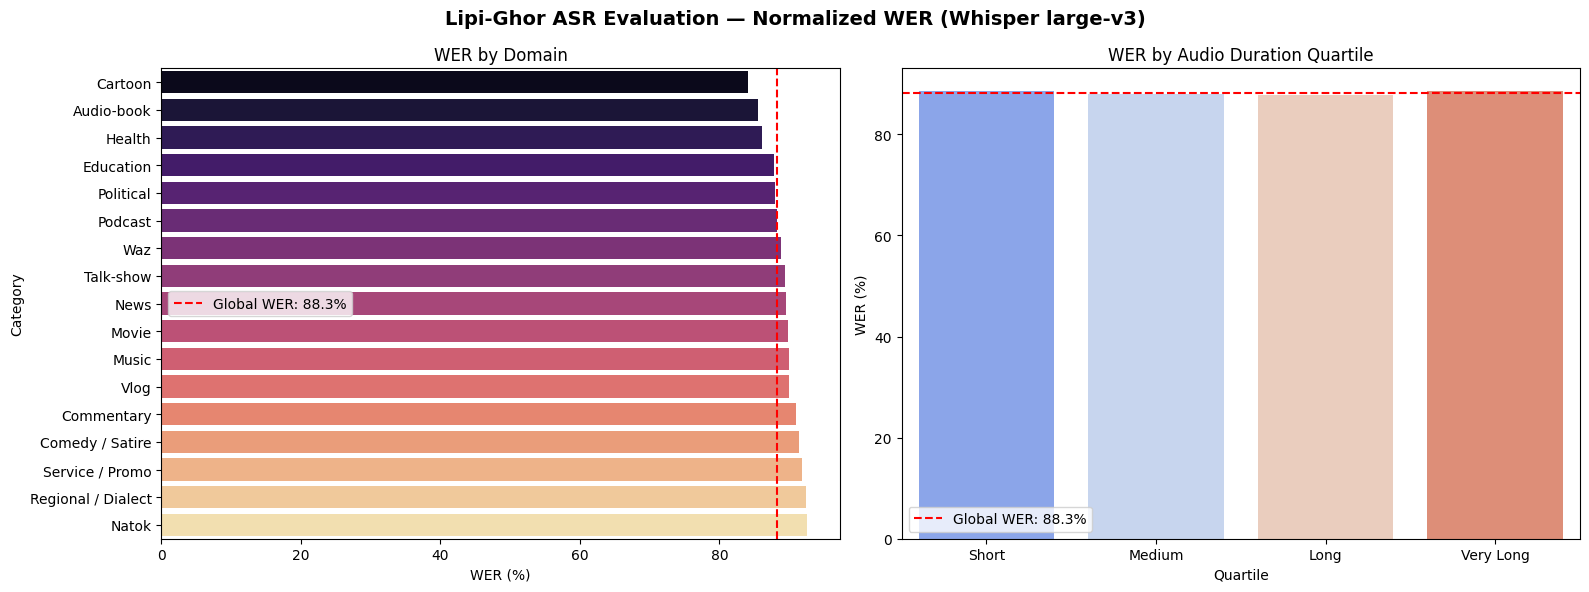


✅ Plot saved to /kaggle/working/whisperv3_wer_evaluation.png


In [16]:
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

print("========================================")
print(" 🚀 LIPI-GHOR ASR EVALUATION PIPELINE")
print("========================================")

# --- 1. Load and Merge Data ---
df_pred = pd.read_csv('/kaggle/working/whisperv3_lipighor_final_fixed.csv')
df_pred = df_pred.rename(columns={'id': 'video_id', 'transcript': 'prediction'})

df_eval = pd.merge(df_text, df_pred, on='video_id', how='inner')
df_eval = pd.merge(df_eval, df_meta[['video_id', 'category', 'duration_sec']], on='video_id', how='inner')
df_eval = df_eval.dropna(subset=['text', 'prediction'])

# --- 2. Normalization ---
BN_DIGITS = str.maketrans('0123456789', '০১২৩৪৫৬৭৮৯')

def clean_bengali(t, normalize_digits=True):
    t = str(t).strip()
    # Remove zero-width characters (ZWJ, ZWNJ, ZWSP)
    t = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', t)
    # Normalize unicode to NFC
    t = unicodedata.normalize('NFC', t)
    # Normalize ASCII digits to Bengali digits
    if normalize_digits:
        t = t.translate(BN_DIGITS)
    # Keep Bengali chars, Bengali digits, spaces only
    t = re.sub(r'[^\u0980-\u09FF\s০-৯]', '', t)
    # Normalize whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# --- 3. Apply Cleaning ---
df_eval['gt_clean'] = df_eval['text'].apply(clean_bengali)
df_eval['pred_clean'] = df_eval['prediction'].apply(clean_bengali)

df_eval = df_eval[df_eval['gt_clean'].str.len() > 0]
df_eval['pred_clean'] = df_eval['pred_clean'].replace('', ' ')

print(f"✅ Data Merged & Cleaned. Total valid utterances for evaluation: {len(df_eval):,}")

# --- 4. Global WER (Raw vs Normalized) ---
raw_wer  = jiwer.wer(df_eval['text'].tolist(), df_eval['prediction'].tolist())
norm_wer = jiwer.wer(df_eval['gt_clean'].tolist(), df_eval['pred_clean'].tolist())
norm_cer = jiwer.cer(df_eval['gt_clean'].tolist(), df_eval['pred_clean'].tolist())
norm_mer = jiwer.mer(df_eval['gt_clean'].tolist(), df_eval['pred_clean'].tolist())
norm_wil = jiwer.wil(df_eval['gt_clean'].tolist(), df_eval['pred_clean'].tolist())

print("\n--- Global ASR Performance ---")
print(f"Raw WER:             {raw_wer*100:.2f}%")
print(f"Normalized WER:      {norm_wer*100:.2f}%")
print(f"Normalization Delta: {(raw_wer - norm_wer)*100:.2f}%  ← artifact removed")
print(f"CER:                 {norm_cer*100:.2f}%")
print(f"MER:                 {norm_mer*100:.2f}%")
print(f"WIL:                 {norm_wil*100:.2f}%")

# --- 5. Domain-Based WER ---
domain_results = []
for category, group in df_eval.groupby('category'):
    if len(group) == 0:
        continue
    wer = jiwer.wer(group['gt_clean'].tolist(), group['pred_clean'].tolist())
    domain_results.append({'Category': category, 'Files': len(group), 'WER (%)': round(wer * 100, 2)})

df_domain = pd.DataFrame(domain_results).sort_values('WER (%)')
print("\n--- Domain-Based WER ---")
print(df_domain.to_string(index=False))

# --- 6. Duration-Based WER ---
df_eval['duration_quartile'] = pd.qcut(
    df_eval['duration_sec'], q=4,
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

duration_results = []
for quartile, group in df_eval.groupby('duration_quartile', observed=True):
    wer = jiwer.wer(group['gt_clean'].tolist(), group['pred_clean'].tolist())
    duration_results.append({'Quartile': quartile, 'Files': len(group), 'WER (%)': round(wer * 100, 2)})

df_duration = pd.DataFrame(duration_results)
print("\n--- Duration-Based WER ---")
print(df_duration.to_string(index=False))

# --- 7. Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lipi-Ghor ASR Evaluation — Normalized WER (Whisper large-v3)', fontsize=14, fontweight='bold')

sns.barplot(data=df_domain, x='WER (%)', y='Category', ax=axes[0], palette='magma')
axes[0].set_title('WER by Domain')
axes[0].axvline(norm_wer * 100, color='red', linestyle='--', label=f'Global WER: {norm_wer*100:.1f}%')
axes[0].legend()

sns.barplot(data=df_duration, x='Quartile', y='WER (%)', ax=axes[1], palette='coolwarm')
axes[1].set_title('WER by Audio Duration Quartile')
axes[1].axhline(norm_wer * 100, color='red', linestyle='--', label=f'Global WER: {norm_wer*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/whisperv3_wer_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to /kaggle/working/whisperv3_wer_evaluation.png")

In [17]:
# --- DIAGNOSTIC: Inspect GT vs Prediction ---
sample = df_eval[['video_id', 'category', 'gt_clean', 'pred_clean']].sample(10, random_state=42)

for _, row in sample.iterrows():
    print(f"\nCategory: {row['category']}")
    print(f"GT:   {row['gt_clean'][:200]}")
    print(f"PRED: {row['pred_clean'][:200]}")
    print("-" * 60)


Category: Audio-book
GT:   বন্ধুরা নমস্কার এসো গল্পশনে ইউটিউব চ্যানেলে আপনাদের সবাইকে স্বাগত আপনারা শুনছেন শিরসেন্দু মুখোপাধ্যায়ের বিখ্যাত উপন্যাস কাগজের বউ আমার পাঠ যদি আপনাদের ভালো লেগে থাকে তাহলে অনুরোধ করব ভিডিওটিকে একটি ল
PRED: ন্ধুরা নমস্কার এশো গল্পোশুনি ইউট্যুব চানেলে আপনাদের সভাইকে সাগতো আপনাদা শুন্ছেন শির্ষেন্দ মখোবাদ্ধায়ের বিখা তাদেরকে উনুরত করবো অবিলম্বে চানেলটিকে সাবস্কাইব করে পাসে থাকা বেল আইকনটি টিপে দিতে যাতে আমা
------------------------------------------------------------

Category: Audio-book
GT:   কল্পনা করুন আপনি একজন সাধারণ মানুষ যেমনটা বাকি সবাই কিন্তু আপনার মধ্যে একটা আগুন রয়েছে একটা চাহিদা রয়েছে কিছু বড় করার একটা খায়েশ রয়েছে একদিন আপনার কাছে এত টাকা হবে যে কখনো কোন জিনিসের জন্য চিন্তা
PRED: কল্পনা করুন আপনি এক জন সাধারন মানোষ জমনতা বাকি সবাই কিন্তো আপনার মধ্যে একটা আগন রোয়েছে একটা চাহিদা রোয়েছে কিছো বা আর আমি এখন কেনও হতে পারে নি এ প্রস্নতিক জবাবি পাবেন এই বৈটিতে এ বয় হাউ টু গেট রিচ য
------------------------------------------------------------

Categ

In [18]:
# Flag alignment failures and hallucinations
def detect_hallucination(text, threshold=5):
    """Detect repeated word loops"""
    words = text.split()
    if len(words) < threshold:
        return False
    for i in range(len(words) - threshold):
        if len(set(words[i:i+threshold])) == 1:
            return True
    return False

df_eval['hallucination'] = df_eval['pred_clean'].apply(detect_hallucination)

print(f"Hallucination cases: {df_eval['hallucination'].sum()}")
print(f"Clean cases: {(~df_eval['hallucination']).sum()}")

# WER on clean subset only
df_clean = df_eval[~df_eval['hallucination']]
clean_wer = jiwer.wer(df_clean['gt_clean'].tolist(), df_clean['pred_clean'].tolist())
print(f"\nWER excluding hallucinations: {clean_wer*100:.2f}%")

Hallucination cases: 602
Clean cases: 413

WER excluding hallucinations: 86.58%


# endswith

In [23]:
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("========================================")
print(" 🚀 LIPI-GHOR ASR EVALUATION PIPELINE")
print("========================================")

# --- 1. Load and Merge Data ---
# Load predictions
df_pred = pd.read_csv('/kaggle/working/whisperv3_lipighor_final_fixed.csv')

# Rename columns so they align perfectly
df_pred = df_pred.rename(columns={'id': 'video_id', 'transcript': 'prediction'})

# Merge Ground Truth (df_text) + Predictions (df_pred) + Metadata (df_meta)
df_eval = pd.merge(df_text, df_pred, on='video_id', how='inner')
df_eval = pd.merge(df_eval, df_meta[['video_id', 'category', 'duration_sec']], on='video_id', how='inner')

# Drop any rows where extraction failed
df_eval = df_eval.dropna(subset=['text', 'prediction'])

# --- 2. Clean Text for Fair Evaluation ---
# Punctuation and extra spaces artificially inflate WER. We must remove them.
def clean_for_eval(t):
    t = str(t).strip()
    t = re.sub(r'[^\w\s]', '', t) # Remove punctuation
    t = re.sub(r'\s+', ' ', t)    # Normalize spaces
    return t

df_eval['gt_clean'] = df_eval['text'].apply(clean_for_eval)
df_eval['pred_clean'] = df_eval['prediction'].apply(clean_for_eval)

# Ensure no empty strings are passed to jiwer (causes division by zero)
df_eval = df_eval[(df_eval['gt_clean'].str.len() > 0)]
# Fill empty predictions with a blank space to penalize them properly
df_eval['pred_clean'] = df_eval['pred_clean'].replace('', ' ') 

print(f"✅ Data Merged & Cleaned. Total valid utterances for evaluation: {len(df_eval):,}")

 🚀 LIPI-GHOR ASR EVALUATION PIPELINE
✅ Data Merged & Cleaned. Total valid utterances for evaluation: 1,019


In [24]:
# --- 3. Global Metrics (UPDATED FOR JIWER 3.0+) ---
ground_truths = df_eval['gt_clean'].tolist()
predictions = df_eval['pred_clean'].tolist()

# Calculate metrics individually
global_wer = jiwer.wer(ground_truths, predictions)
global_cer = jiwer.cer(ground_truths, predictions)
global_mer = jiwer.mer(ground_truths, predictions)
global_wil = jiwer.wil(ground_truths, predictions)

print("\n--- 🌍 Global ASR Performance ---")
print(f"Global WER (Word Error Rate):       {global_wer * 100:.2f}%")
print(f"Global CER (Character Error Rate):  {global_cer * 100:.2f}%")
print(f"Global MER (Match Error Rate):      {global_mer * 100:.2f}%")
print(f"Global WIL (Word Information Lost): {global_wil * 100:.2f}%")

# --- 4. Domain-Based Evaluation (UPDATED) ---
print("\n--- 📊 Domain-Based WER & CER ---")
def get_metrics(df_group):
    gt = df_group['gt_clean'].tolist()
    pr = df_group['pred_clean'].tolist()
    
    return pd.Series({
        'WER %': jiwer.wer(gt, pr) * 100, 
        'CER %': jiwer.cer(gt, pr) * 100,
        'Files': len(df_group)
    })

domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
print(domain_stats.round(2))

# --- 5. Duration-Based Evaluation (UPDATED) ---
print("\n--- ⏱️ Duration-Based WER ---")
# Split durations into 4 equal quartiles (Short, Medium, Long, Very Long)
df_eval['duration_bin'] = pd.qcut(df_eval['duration_sec'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)
print(duration_stats.round(2))


--- 🌍 Global ASR Performance ---
Global WER (Word Error Rate):       84.53%
Global CER (Character Error Rate):  72.92%
Global MER (Match Error Rate):      83.96%
Global WIL (Word Information Lost): 92.43%

--- 📊 Domain-Based WER & CER ---


/tmp/ipykernel_55/2464990262.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
/tmp/ipykernel_55/2464990262.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


                    WER %  CER %  Files
category                               
Cartoon             79.96  67.98   23.0
Audio-book          80.87  69.80  277.0
Health              83.18  74.57    2.0
Education           84.38  73.15   39.0
Political           84.58  73.52   29.0
Waz                 85.15  72.23   66.0
Podcast             85.16  73.67   62.0
Vlog                85.97  73.35   42.0
Talk-show           86.17  74.47  176.0
Movie               86.19  74.73   74.0
News                86.23  73.26   35.0
Music               86.71  75.85   37.0
Commentary          88.20  76.01   13.0
Comedy / Satire     88.64  76.84   43.0
Service / Promo     88.98  76.56    2.0
Natok               89.01  76.38   95.0
Regional / Dialect  90.74  77.03    4.0

--- ⏱️ Duration-Based WER ---
              WER %  CER %  Files
duration_bin                     
Short         85.01  73.54  255.0
Medium        84.25  72.65  255.0
Long          84.00  72.46  254.0
Very Long     84.93  73.24  255.0


/tmp/ipykernel_55/2464990262.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


# Titu-conformer-large

In [3]:
import os
import pandas as pd
from pathlib import Path
from huggingface_hub import hf_hub_download

# ── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN             = secret_value_0  # Replace with your actual token
OUTPUT_REPO_ID       = "hasans090/titu_conformer_inference_lp"
DATASET_AUDIO_FOLDER = "data"
OUTPUT_CSV           = "/kaggle/working/titu_conformer_lipighor_final.csv"
LOCAL_AUDIO_CACHE    = "/kaggle/working/audio_cache"

os.makedirs(LOCAL_AUDIO_CACHE, exist_ok=True)
print("✅ Config ready")

# ── Resume Logic ──────────────────────────────────────────────────────────────
def load_existing_csv_from_hf(output_repo, csv_filename, token):
    try:
        path = hf_hub_download(
            repo_id        = output_repo,
            filename       = csv_filename,
            repo_type      = "dataset",
            token          = token,
            force_download = True,
        )
        df = pd.read_csv(path)
        print(f"✅ Loaded from HF — {len(df)} rows done so far")
        return df
    except Exception as e:
        # This will trigger if the file doesn't exist yet (first run)
        print(f"ℹ️ No existing CSV on HF (starting fresh)")
        return pd.DataFrame() # Return empty DF instead of None for easier concatenation later

# Execute
hf_df = load_existing_csv_from_hf(OUTPUT_REPO_ID, Path(OUTPUT_CSV).name, HF_TOKEN)

✅ Config ready


titu_conformer_lipighor_final.csv:   0%|          | 0.00/92.1M [00:00<?, ?B/s]

✅ Loaded from HF — 1019 rows done so far


In [4]:
hf_df.to_csv('titu_conformer_lipighor_final.csv')

In [5]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.4 MB/s eta 0:00:00:00:01


In [6]:
df_text = pd.read_csv('/kaggle/input/notebooks/sanjidh090/lipighor-statistics-part-01/combined_metadata_V2_normalized.csv')
df_meta = pd.read_csv('/kaggle/input/datasets/sanjidh090/lipighor-metadata/lipi_ghor_metadata (1).csv')

In [8]:
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("========================================")
print(" 🚀 LIPI-GHOR ASR EVALUATION PIPELINE")
print("========================================")

# --- 1. Load and Merge Data ---
# Load predictions
df_pred = pd.read_csv('/kaggle/working/titu_conformer_lipighor_final.csv')

# Rename columns so they align perfectly
df_pred = df_pred.rename(columns={'id': 'video_id', 'transcript': 'prediction'})

# Merge Ground Truth (df_text) + Predictions (df_pred) + Metadata (df_meta)
df_eval = pd.merge(df_text, df_pred, on='video_id', how='inner')
df_eval = pd.merge(df_eval, df_meta[['video_id', 'category', 'duration_sec']], on='video_id', how='inner')

# Drop any rows where extraction failed
df_eval = df_eval.dropna(subset=['text', 'prediction'])

# --- 2. Clean Text for Fair Evaluation ---
# Punctuation and extra spaces artificially inflate WER. We must remove them.
def clean_for_eval(t):
    t = str(t).strip()
    t = re.sub(r'[^\w\s]', '', t) # Remove punctuation
    t = re.sub(r'\s+', ' ', t)    # Normalize spaces
    return t

df_eval['gt_clean'] = df_eval['text'].apply(clean_for_eval)
df_eval['pred_clean'] = df_eval['prediction'].apply(clean_for_eval)

# Ensure no empty strings are passed to jiwer (causes division by zero)
df_eval = df_eval[(df_eval['gt_clean'].str.len() > 0)]
# Fill empty predictions with a blank space to penalize them properly
df_eval['pred_clean'] = df_eval['pred_clean'].replace('', ' ') 

print(f"✅ Data Merged & Cleaned. Total valid utterances for evaluation: {len(df_eval):,}")

 🚀 LIPI-GHOR ASR EVALUATION PIPELINE
✅ Data Merged & Cleaned. Total valid utterances for evaluation: 1,019


In [9]:
# --- 3. Global Metrics (UPDATED FOR JIWER 3.0+) ---
ground_truths = df_eval['gt_clean'].tolist()
predictions = df_eval['pred_clean'].tolist()

# Calculate metrics individually
global_wer = jiwer.wer(ground_truths, predictions)
global_cer = jiwer.cer(ground_truths, predictions)
global_mer = jiwer.mer(ground_truths, predictions)
global_wil = jiwer.wil(ground_truths, predictions)

print("\n--- 🌍 Global ASR Performance ---")
print(f"Global WER (Word Error Rate):       {global_wer * 100:.2f}%")
print(f"Global CER (Character Error Rate):  {global_cer * 100:.2f}%")
print(f"Global MER (Match Error Rate):      {global_mer * 100:.2f}%")
print(f"Global WIL (Word Information Lost): {global_wil * 100:.2f}%")

# --- 4. Domain-Based Evaluation (UPDATED) ---
print("\n--- 📊 Domain-Based WER & CER ---")
def get_metrics(df_group):
    gt = df_group['gt_clean'].tolist()
    pr = df_group['pred_clean'].tolist()
    
    return pd.Series({
        'WER %': jiwer.wer(gt, pr) * 100, 
        'CER %': jiwer.cer(gt, pr) * 100,
        'Files': len(df_group)
    })

domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
print(domain_stats.round(2))

# --- 5. Duration-Based Evaluation (UPDATED) ---
print("\n--- ⏱️ Duration-Based WER ---")
# Split durations into 4 equal quartiles (Short, Medium, Long, Very Long)
df_eval['duration_bin'] = pd.qcut(df_eval['duration_sec'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)
print(duration_stats.round(2))


--- 🌍 Global ASR Performance ---
Global WER (Word Error Rate):       30.51%
Global CER (Character Error Rate):  18.23%
Global MER (Match Error Rate):      27.40%
Global WIL (Word Information Lost): 39.21%

--- 📊 Domain-Based WER & CER ---


/tmp/ipykernel_54/2464990262.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  domain_stats = df_eval.groupby('category').apply(get_metrics).sort_values(by='WER %')
/tmp/ipykernel_54/2464990262.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)


                    WER %  CER %  Files
category                               
Audio-book          21.02  12.36  277.0
Health              22.89  13.12    2.0
Cartoon             26.56  15.41   23.0
Political           27.66  16.00   29.0
News                28.03  15.79   35.0
Talk-show           29.88  17.90  176.0
Education           30.09  16.36   39.0
Podcast             32.51  18.88   62.0
Commentary          32.63  18.48   13.0
Waz                 35.75  21.09   66.0
Movie               36.39  22.32   74.0
Service / Promo     37.07  20.14    2.0
Vlog                41.21  26.46   42.0
Natok               44.37  28.84   95.0
Comedy / Satire     44.56  27.69   43.0
Music               46.09  27.13   37.0
Regional / Dialect  57.01  35.29    4.0

--- ⏱️ Duration-Based WER ---
              WER %  CER %  Files
duration_bin                     
Short         30.54  18.23  255.0
Medium        29.14  17.44  255.0
Long          28.46  16.81  254.0
Very Long     32.60  19.61  255.0


/tmp/ipykernel_54/2464990262.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duration_stats = df_eval.groupby('duration_bin').apply(get_metrics)
